# pyena Quickstart

A 5-minute tour of pyena — a rENA-exact Python implementation of Epistemic
Network Analysis.

This notebook covers:

1. **SVD-based ENA** in one line with the `ENA` estimator
2. **Visualization** with 95% confidence ellipses
3. **Means rotation** for two-group comparison
4. **Statistical comparison** and **reproducibility metrics**

For the numerical validation against the R package `rENA`, see
`02_rena_parity.ipynb`.

In [1]:
import pandas as pd
from pyena import ENA

# Load the bundled 90-unit toy dataset (3 groups × 30 units × 20 turns)
df = pd.read_csv("../tests/data/toy_data_n90.csv")
print(f"shape: {df.shape}")
df.head()

shape: (1800, 9)


,unit,group,conversation,turn,Data,Theory,Question,Example,Critique
0,At01,A_tight,At01_session,0,1,1,0,0,0
1,At01,A_tight,At01_session,1,1,0,0,1,0
2,At01,A_tight,At01_session,2,1,0,0,0,0
3,At01,A_tight,At01_session,3,0,0,0,1,0
4,At01,A_tight,At01_session,4,0,0,0,0,1


## 1. Fit an ENA model

The `ENA` estimator follows the scikit-learn pattern. With `rotation='svd'`
(the default), it computes the standard ENA pipeline:

1. rENA-exact adjacency vectors from the moving-stanza window
2. Sphere normalization
3. Centering and SVD onto the top components

In [2]:
codes = ["Data", "Theory", "Question", "Example", "Critique"]

ena = ENA(codes=codes, window_size=4).fit(df)

print(f"coords:           {ena.coords_.shape}")
print(f"singular values:  {ena.singular_values_.round(3)}")
print(f"explained var:    {(ena.singular_values_**2 / (ena.singular_values_**2).sum()).round(3)}")
print(f"first 3 units:")
for uid, xy in zip(ena.unit_ids_[:3], ena.coords_[:3]):
    print(f"  {uid}: ({xy[0]:+.4f}, {xy[1]:+.4f})")

coords:           (90, 2)
singular values:  [4.841 2.02 ]
explained var:    [0.852 0.148]
first 3 units:
  At01: (+0.4483, -0.1674)
  At02: (+0.4694, -0.3240)
  At03: (+0.3780, +0.0189)


## 2. Visualize the ENA space

`ena.plot()` shows each unit as a dot, each group's centroid as an `X`, and
draws a 95% confidence ellipse per group. Because the units are coloured by
the `group` column in `df`, we can see how the three conditions land in
ENA space.

The toy dataset has three groups designed to test pyena's behaviour:

- `A_tight`  — base probabilities of group A, low run-to-run jitter (0.03)
- `A_loose`  — same base probabilities as A, high jitter (0.20)
- `B_tight`  — different base probabilities, low jitter

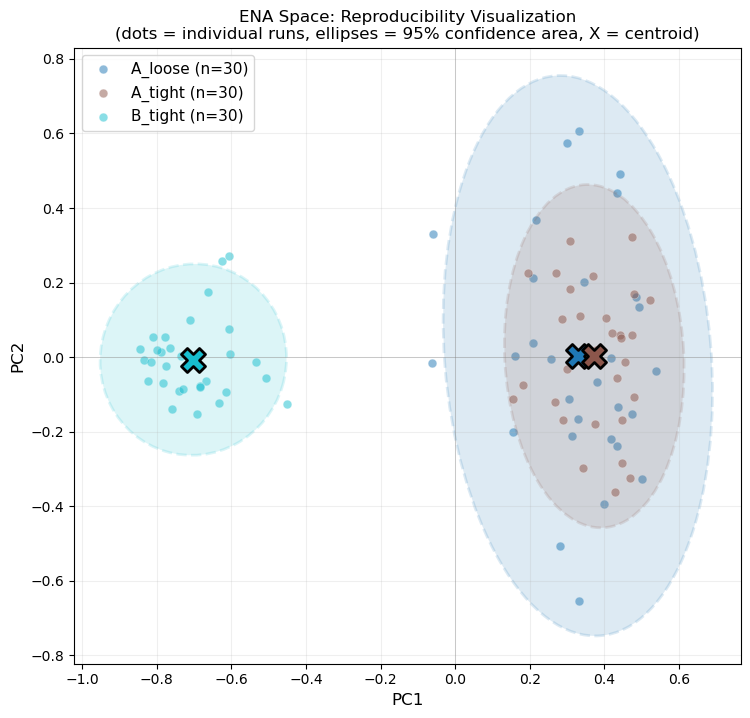

In [3]:
ena.plot();

## 3. Two-group analysis with Means Rotation

If you're comparing two specific groups, **Means Rotation** aligns the first
axis with the group-mean difference, so any separation between those two
groups is concentrated on the x-axis. This is rENA's `ena.rotate.by.mean`
behaviour, reproduced exactly.

Below we compare `A_tight` vs `B_tight`. The two groups have different base
code probabilities, so MR1 should separate them cleanly.

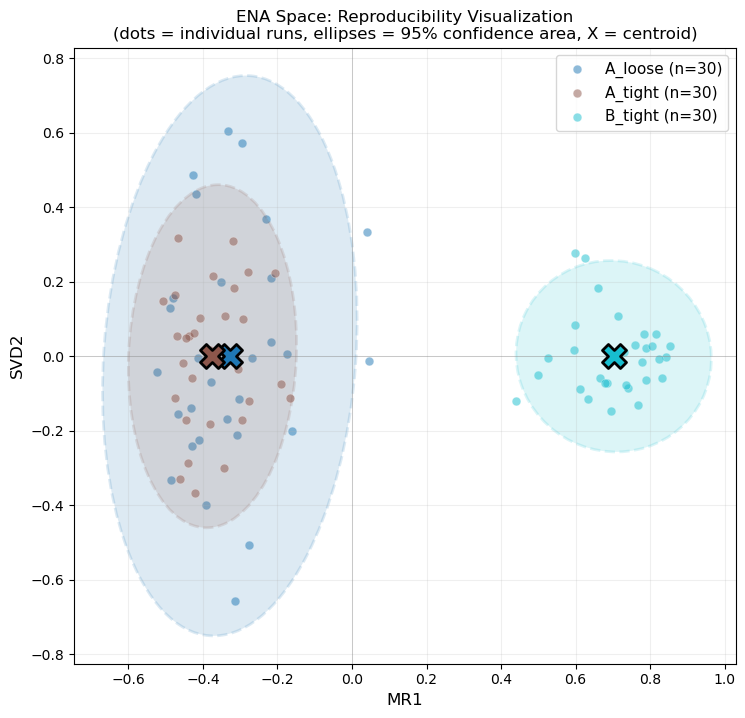

In [5]:
ena_mr = ENA(
    codes=codes,
    window_size=4,
    rotation="means",
    mr_groups=("A_tight", "B_tight"),
).fit(df)

ena_mr.plot(xlabel="MR1", ylabel="SVD2");

## 4. Statistical comparison and reproducibility

With the model fitted in MR mode, two convenience methods give you the
quantitative summary:

- `ena.compare(axis='x')` — Welch's t, Mann-Whitney U, and a permutation
  test on the MR1 axis (uses `mr_groups` by default).
- `ena.reproducibility()` — four indicators per group: centroid dispersion,
  pairwise distance, 95% ellipse area, convex hull area. Lower values = more
  reproducible.

In [6]:
# Statistical test on MR1
result = ena_mr.compare(axis="x")
print(f"A_tight vs B_tight on MR1:")
print(f"  Welch's t      : t = {result['welch_t']:.2f}, p = {result['welch_p']:.2e}")
print(f"  Mann-Whitney U : U = {result['mannwhitney_U']:.0f}, p = {result['mannwhitney_p']:.2e}")
print(f"  Permutation    : p = {result['permutation_p']:.4f}  (n = {result['permutation_n']})")
print(f"  Cohen's d      : {result['cohens_d']:.2f}")
print()

# Reproducibility per group
print("Reproducibility (lower = more reproducible):")
ena_mr.reproducibility().round(4)

A_tight vs B_tight on MR1:
  Welch's t      : t = -41.72, p = 2.78e-44
  Mann-Whitney U : U = 0, p = 3.02e-11
  Permutation    : p = 0.0000  (n = 10000)
  Cohen's d      : -10.77

Reproducibility (lower = more reproducible):


,n,centroid_x,centroid_y,centroid_dispersion_mean,centroid_dispersion_std,pairwise_distance_mean,pairwise_distance_max,ellipse_95_area,convex_hull_area
A_loose,30.0,-0.3279,0.0009,0.2863,0.1677,0.4141,1.2630,0.8008,0.4609
A_tight,30.0,-0.3745,-0.0005,0.1844,0.0917,0.2616,0.6851,0.3259,0.1688
B_tight,30.0,0.7024,-0.0005,0.1331,0.0635,0.1862,0.4427,0.2115,0.1033


## Where to go next

This 5-minute tour showed the core API. For deeper material:

- **`02_rena_parity.ipynb`** — Reproduces the bit-for-bit validation against
  the R package `rENA` 0.3.1 via `rpy2`. Requires R + rENA installed.
- **`tests/`** — 101 automated tests covering reference regression,
  mathematical properties, and external cross-checks. Run `pytest`.
- **`README.md`** — Project overview, full validation table, citation info.
- **Companion paper** — *(in preparation for SoftwareX)*.

### Key references

- Marquart, C. L., Swiecki, Z., Collier, W., Eagan, B., Woodward, R., &
  Shaffer, D. W. (2021). *rENA: Epistemic Network Analysis* (R package
  version 0.3.1).
- Shaffer, D. W., & Ruis, A. R. (2017). *Epistemic Network Analysis: A
  worked example of theory-based learning analytics*. In *Handbook of
  Learning Analytics*.